In [106]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv("/Users/athipongjindaphram/Documents/EV Car Analysis/ev_market_2026.csv")
df.sample()

,brand,model,year,variant,price_usd,battery_capacity_kwh,range_miles,charging_speed_kw,acceleration_0_60_mph,top_speed_mph,...,body_type,cargo_volume_cubic_ft,weight_kg,safety_rating,autopilot_level,country_of_origin,market_segment,annual_sales_units,customer_rating,warranty_years
5,Tesla,Model Y,2023,Performance,119590.27,78.3,251.0,334.6,2.84,200.0,...,Hatchback,35.5,1751.0,5,3,US,Luxury,411764,3.67,5


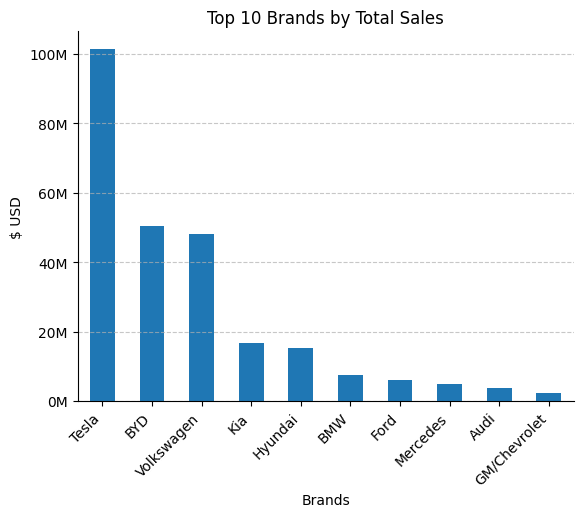

In [172]:
df_top_10 = df.copy()

df_top_10 = df_top_10.groupby("brand")["annual_sales_units"].sum()
df_top_10 = df_top_10.sort_values(ascending=False).head(10)

ax = df_top_10.plot(kind="bar")

import matplotlib.ticker as mticker

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, pos: f'{x/1e6:.0f}M')
)

sns.despine()

plt.title("Top 10 Brands by Total Sales")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.ylabel("$ USD")
plt.xlabel("Brands")
plt.show()

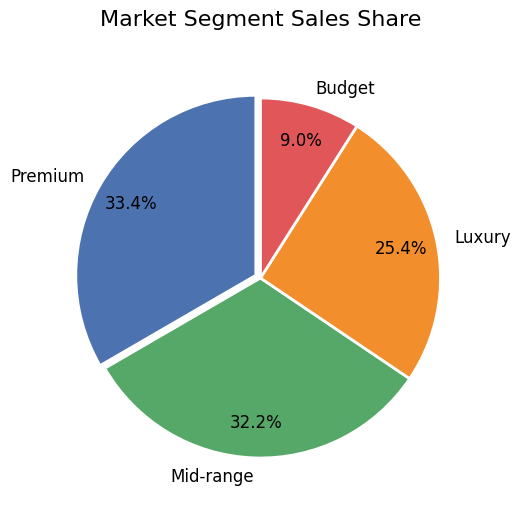

In [ ]:
df_segment = df.copy()
df_segment = df_segment.groupby("market_segment")["annual_sales_units"].sum()
df_segment = df_segment.sort_values(ascending=False)

colors = ["#4C72B0", "#55A868", "#F28E2B", "#E15759"]

explode = [0.03, 0, 0, 0]

df_segment.plot(kind="pie",
                autopct="%1.1f%%",
                startangle=90,
                colors=colors,
                explode=explode,
                wedgeprops={
                    "edgecolor": "white",
                    "linewidth": 2},
                    pctdistance=0.8,
                    textprops={"fontsize": 12}
                    )

plt.tight_layout()
plt.ylabel("")
plt.title(
    "Market Segment Sales Share",
    fontsize=16,
    pad=20
)
plt.show()

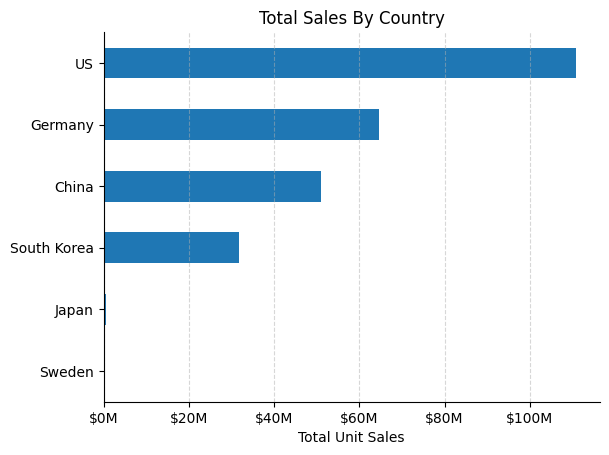

In [170]:
df_country = df.copy()

df_country = df_country.groupby("country_of_origin")["annual_sales_units"].sum()
df_country = df_country.sort_values()

ax = df_country.plot(kind="barh")

import matplotlib.ticker as mticker

ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda y, pos: f'${y/1e6:.0f}M')
)

sns.despine()

plt.ylabel("")
plt.xlabel("Total Unit Sales")
plt.title("Total Sales By Country")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.show()